Skipping profile_hydro.nc: missing required variables. Found: ['time', 'countries', '__xarray_dataarray_variable__']
          technology  n_buses  n_bins  n_years  n_times  mean_profile  \
0  128_offwind-float       56       1        1     8760      0.362295   
1     128_offwind-ac       56       1        1     8760      0.387848   
2     128_offwind-dc       40       1        1     8760      0.497991   
3         128_onwind      128       1        1     8760      0.162092   
4          128_solar      128       1        1     8760      0.127030   
5     128_solar-hsat      128       1        1     8760      0.152734   

   max_profile  total_p_nom_max_MW  max_p_nom_max_MW  mean_p_nom_max_MW  \
0     0.885500        2.299128e+06      3.555595e+05       41055.854846   
1     0.885500        4.697220e+05      5.123691e+04        8387.892167   
2     0.885500        2.758690e+05      3.335051e+04        6896.726046   
3     1.000000        9.615520e+06      7.350982e+05       75121.253130

/tmp/ipykernel_1645305/570673501.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_buses = ds.dims["bus"]
/tmp/ipykernel_1645305/570673501.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_years = ds.dims.get("year", 1)
<frozen _collections_abc>:807: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/tmp/ipykernel_1645305/570673501.py:30: FutureWarning: The return type of `Dataset.dims` 

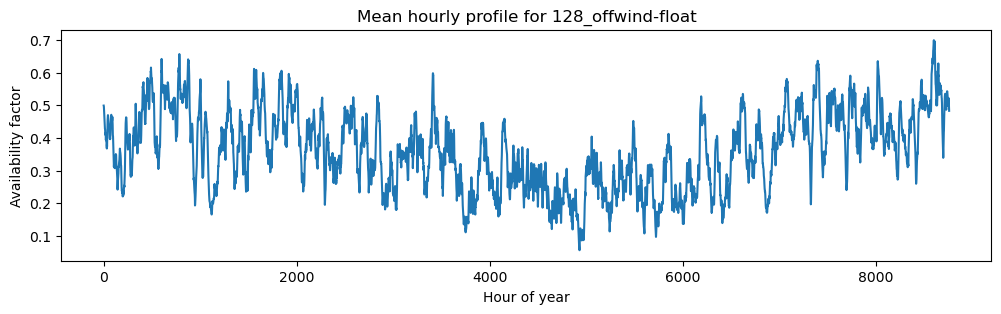

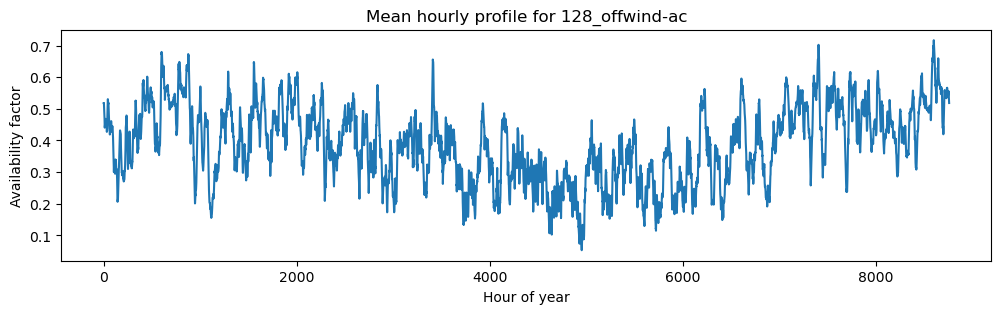

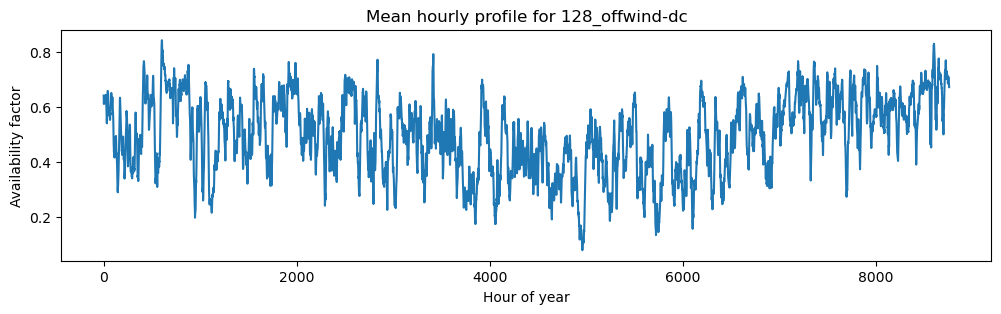

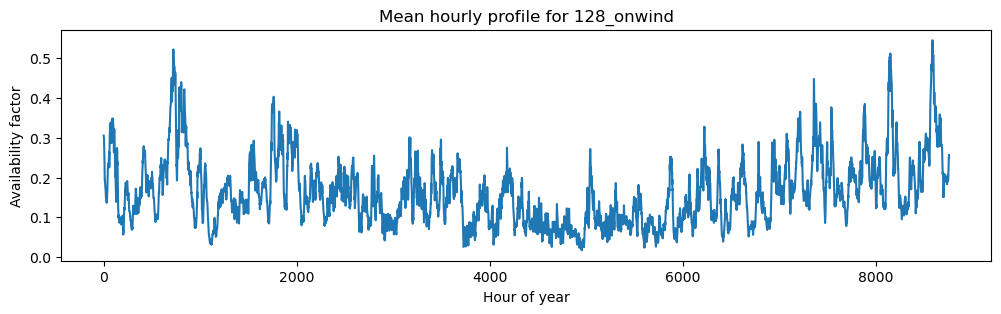

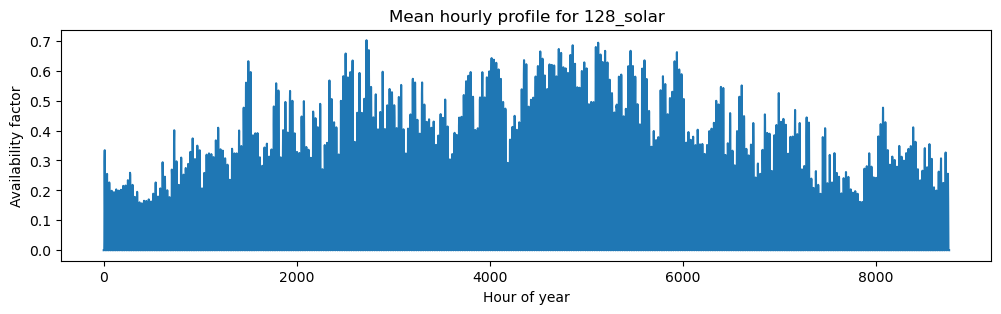

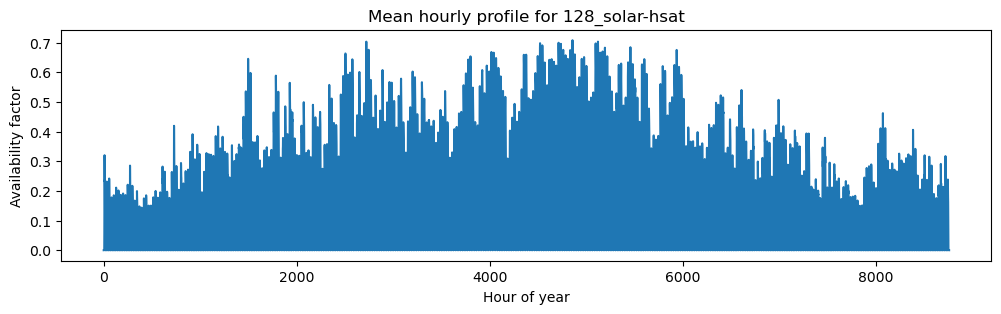

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd

profile_dir = "../resources"
files = [f for f in os.listdir(profile_dir) if f.startswith("profile_") and f.endswith(".nc")]

summary = []

for fname in files:
    tech = fname.replace("profile_", "").replace(".nc", "")
    path = os.path.join(profile_dir, fname)
    ds = xr.open_dataset(path)

    # Check for required variables
    if "profile" not in ds.variables or "p_nom_max" not in ds.variables:
        print(f"Skipping {fname}: missing required variables. Found: {list(ds.variables)}")
        continue

    # Profile stats
    profile = ds["profile"]
    dims = list(profile.dims)
    reduce_dims = [d for d in ["bin", "time"] if d in dims]
    mean_profile = profile.mean(dim=reduce_dims, skipna=True)
    max_profile = profile.max(dim=reduce_dims, skipna=True)
    n_buses = ds.dims["bus"]
    n_bins = ds.dims["bin"] if "bin" in ds.dims else 1
    n_years = ds.dims.get("year", 1)
    n_times = ds.dims["time"]

    # p_nom_max stats
    p_nom_max = ds["p_nom_max"]
    total_p_nom_max = float(p_nom_max.sum())
    max_p_nom_max = float(p_nom_max.max())
    mean_p_nom_max = float(p_nom_max.mean())

    # Average distance stats (if present)
    if "average_distance" in ds.variables:
        avg_dist = ds["average_distance"]
        mean_dist = float(avg_dist.mean())
        max_dist = float(avg_dist.max())
    else:
        mean_dist = np.nan
        max_dist = np.nan

    summary.append({
        "technology": tech,
        "n_buses": n_buses,
        "n_bins": n_bins,
        "n_years": n_years,
        "n_times": n_times,
        "mean_profile": float(mean_profile.mean()),
        "max_profile": float(max_profile.max()),
        "total_p_nom_max_MW": total_p_nom_max,
        "max_p_nom_max_MW": max_p_nom_max,
        "mean_p_nom_max_MW": mean_p_nom_max,
        "mean_distance_km": mean_dist,
        "max_distance_km": max_dist,
    })

# Display as DataFrame
df_summary = pd.DataFrame(summary)
print(df_summary)

# Optionally: plot mean profile for each technology
import matplotlib.pyplot as plt

for fname in files:
    path = os.path.join(profile_dir, fname)
    ds = xr.open_dataset(path)
    if "profile" not in ds.variables:
        continue
    tech = fname.replace("profile_", "").replace(".nc", "")
    profile = ds["profile"]
    reduce_dims = [d for d in ["bus", "bin"] if d in profile.dims]
    mean_hourly = profile.mean(dim=reduce_dims)
    plt.figure(figsize=(12, 3))
    plt.plot(mean_hourly.values.flatten())
    plt.title(f"Mean hourly profile for {tech}")
    plt.xlabel("Hour of year")
    plt.ylabel("Availability factor")
    plt.show()

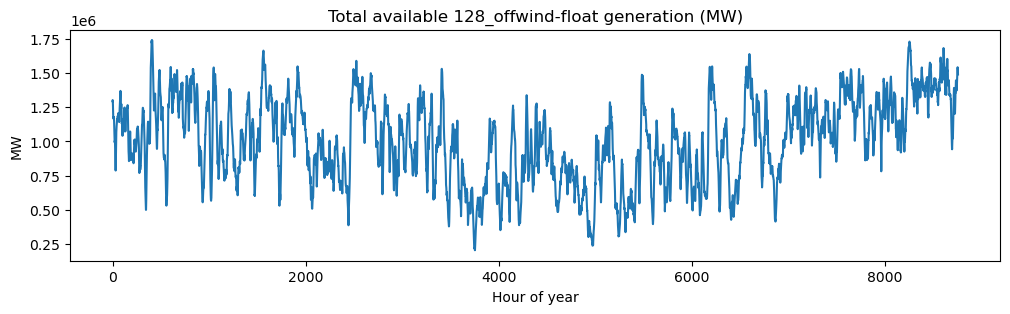

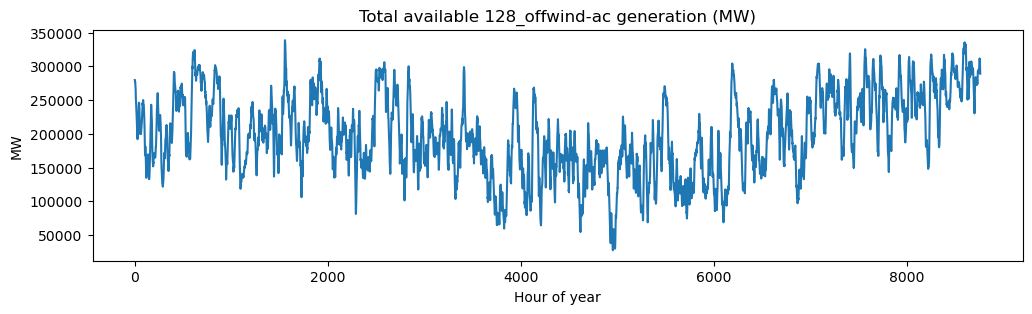

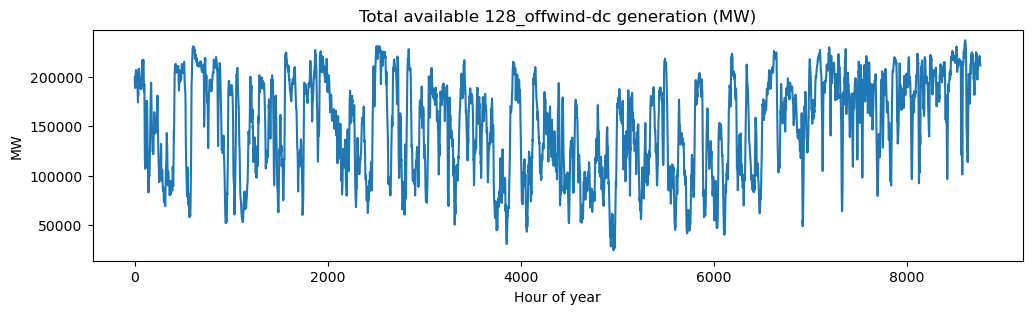

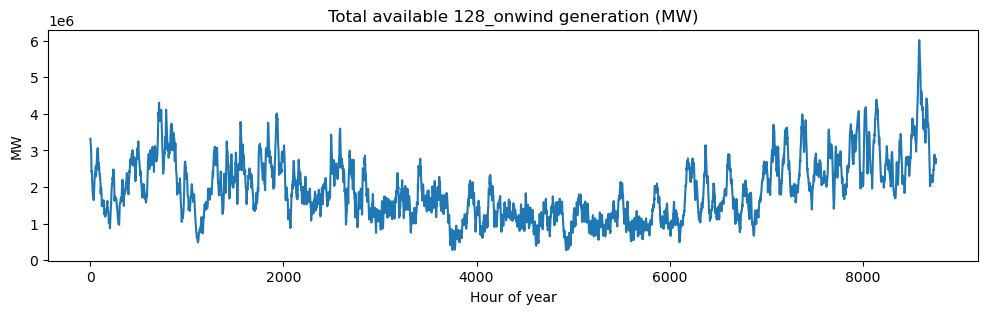

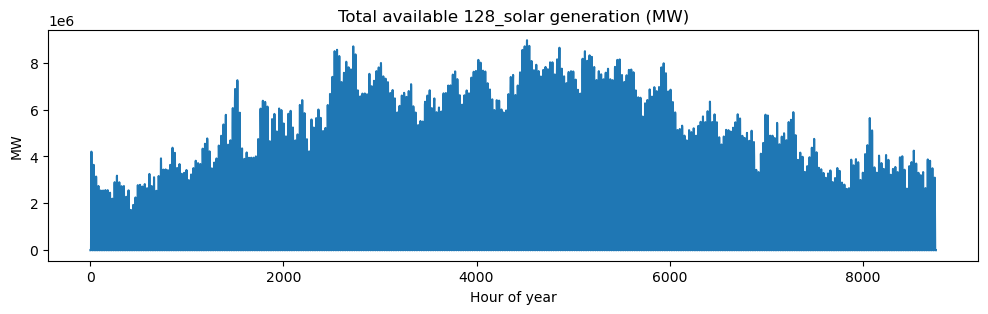

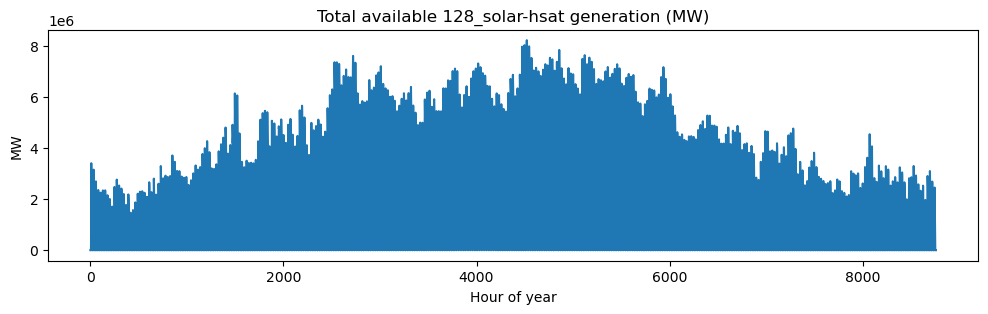

In [2]:
import matplotlib.pyplot as plt

for fname in files:
    tech = fname.replace("profile_", "").replace(".nc", "")
    path = os.path.join(profile_dir, fname)
    ds = xr.open_dataset(path)
    if "profile" not in ds.variables or "p_nom_max" not in ds.variables:
        continue

    profile = ds["profile"]
    p_nom_max = ds["p_nom_max"]

    # Broadcast p_nom_max to match profile dimensions
    # (Assumes p_nom_max dims are a subset of profile dims)
    abs_profile = profile * p_nom_max

    # Sum over all spatial dimensions except time/year
    sum_dims = [d for d in abs_profile.dims if d not in ("time", "year")]
    abs_total = abs_profile.sum(dim=sum_dims)

    # If year is present, average over years
    if "year" in abs_total.dims:
        abs_total = abs_total.mean(dim="year")

    # Plot
    plt.figure(figsize=(12, 3))
    plt.plot(abs_total.values.flatten())
    plt.title(f"Total available {tech} generation (MW)")
    plt.xlabel("Hour of year")
    plt.ylabel("MW")
    plt.show()

No Austrian buses found in profile_128_offwind-float.nc
No Austrian buses found in profile_128_offwind-ac.nc
No Austrian buses found in profile_128_offwind-dc.nc


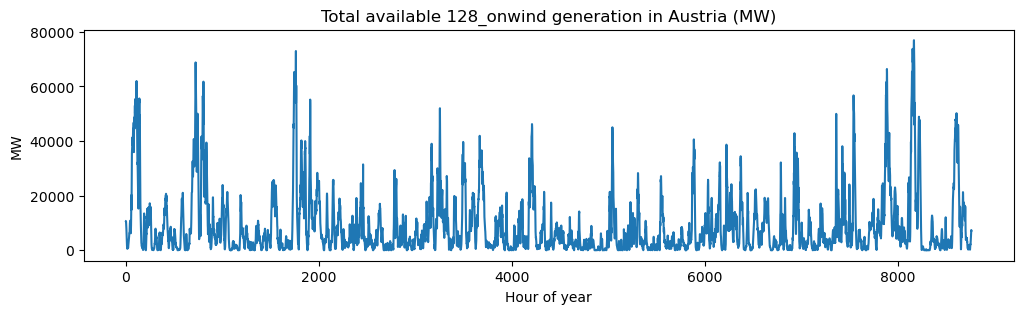

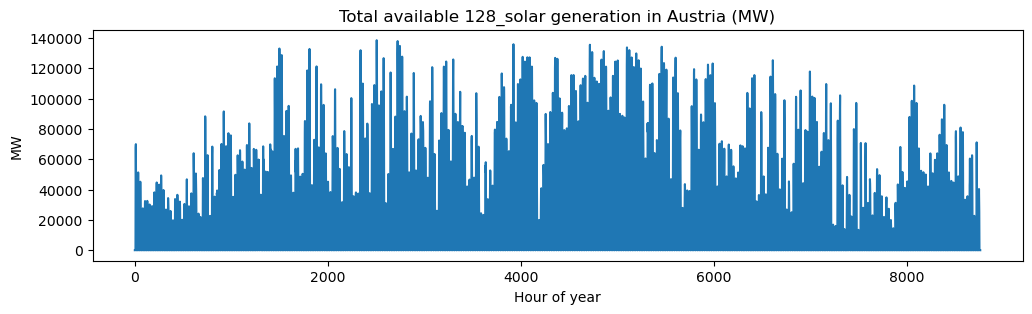

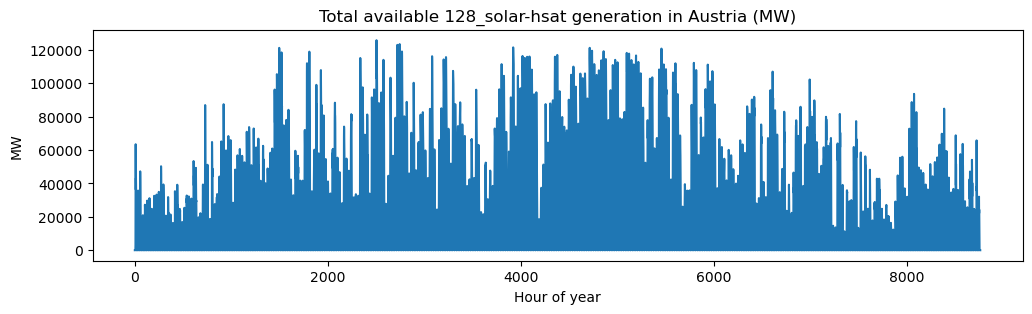

In [3]:
import matplotlib.pyplot as plt

for fname in files:
    tech = fname.replace("profile_", "").replace(".nc", "")
    path = os.path.join(profile_dir, fname)
    ds = xr.open_dataset(path)
    if "profile" not in ds.variables or "p_nom_max" not in ds.variables:
        continue

    profile = ds["profile"]
    p_nom_max = ds["p_nom_max"]

    # Select only Austrian buses (bus names start with "AT")
    at_buses = [b for b in ds.bus.values if str(b).startswith("AT")]
    if not at_buses:
        print(f"No Austrian buses found in {fname}")
        continue

    # Select only AT buses in both profile and p_nom_max
    profile_at = profile.sel(bus=at_buses)
    p_nom_max_at = p_nom_max.sel(bus=at_buses)

    # Multiply per-unit profile by installable capacity
    abs_profile = profile_at * p_nom_max_at

    # Sum over all spatial dims except time/year
    sum_dims = [d for d in abs_profile.dims if d not in ("time", "year")]
    abs_total = abs_profile.sum(dim=sum_dims)

    # If year is present, average over years
    if "year" in abs_total.dims:
        abs_total = abs_total.mean(dim="year")

    # Plot
    plt.figure(figsize=(12, 3))
    plt.plot(abs_total.values.flatten())
    plt.title(f"Total available {tech} generation in Austria (MW)")
    plt.xlabel("Hour of year")
    plt.ylabel("MW")
    plt.show()

In [11]:
import xarray as xr

ds = xr.open_dataset('../resources/profile_128_offwind-ac.nc')
df = ds.to_dataframe()
df

profile     p_nom_max  average_distance
year time                bus                                            
0    2013-01-01 00:00:00 AL0 0  0.010156   3160.441247          7.587357
                         BA0 0  0.000000    350.388233          7.573153
                         BE0 0  0.885500    823.388205         17.861764
                         BG0 0  0.035776   1598.925797         11.223077
                         DE0 5  0.885500   1160.245728         23.793356
...                                  ...           ...               ...
     2013-12-31 23:00:00 SE1 0  0.583654  35394.529804         12.014291
                         SE1 1  0.803415  27494.801484         32.916673
                         SI0 0  0.000000    195.485815          8.672625
                         UA0 1  0.408469  21120.276536         13.221491
                         UA0 2  0.167345   6861.650109         22.731482

[490560 rows x 3 columns]